
# Finite-Time Recovery Boundary in a Minimal Dynamical System

This notebook presents a cleaned and reproducible version of the recovery-boundary analysis.

## Goal
Evaluate whether failure depends only on total load or also on the temporal structure of the perturbation (`rise_time`).

## Main outputs
- Temporal boundary map in `(load, rise_time)` space
- Return map under a strict recovery definition
- Critical load curve as a function of `rise_time`
- Summary statistics for recoverable vs non-recoverable regimes



## 1. Imports and plotting setup


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

output_dir = Path("results_recovery_boundary")
fig_dir = output_dir / "figures"
data_dir = output_dir / "data"
fig_dir.mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)


## 2. Model definition

In [2]:

@dataclass
class ModelParams:
    T: float = 20.0
    dt: float = 0.01
    tau_rec: float = 2.5
    v0: float = 1.0
    collapse_threshold: float = 0.35
    return_tol: float = 0.90
    noise_sigma: float = 0.00
    pulse_center: float = 4.0


def gaussian_pulse(t, load, rise_time, center):
    width = max(rise_time, 1e-3)
    amp = load / (np.sqrt(2 * np.pi) * width)
    return amp * np.exp(-0.5 * ((t - center) / width) ** 2)


def simulate_recovery_clipped(params: ModelParams, load: float, rise_time: float):
    t = np.arange(0, params.T, params.dt)
    v = np.zeros_like(t)
    u = gaussian_pulse(t, load=load, rise_time=rise_time, center=params.pulse_center)

    v[0] = params.v0

    for i in range(1, len(t)):
        noise = params.noise_sigma * rng.normal()
        dv = ((1.0 - v[i - 1]) / params.tau_rec - u[i - 1]) * params.dt + noise * np.sqrt(params.dt)
        v[i] = np.clip(v[i - 1] + dv, 0.0, 1.2)

    return t, u, v


def extract_metrics_strict(
    t,
    u,
    v,
    collapse_threshold=0.35,
    return_tol=0.90,
    max_return_time=6.0,
    final_window_points=50,
    require_stable_final=True,
):
    baseline = 1.0
    v_min = np.min(v)
    min_idx = np.argmin(v)

    collapsed = bool(v_min <= collapse_threshold)
    collapse_time = float(t[min_idx]) if collapsed else np.nan

    return_idx = None
    for i in range(min_idx, len(v)):
        if v[i] >= return_tol * baseline:
            return_idx = i
            break

    tau_return_raw = float(t[return_idx] - t[min_idx]) if return_idx is not None else np.nan
    fast_enough = return_idx is not None and tau_return_raw <= max_return_time

    final_mean = float(np.mean(v[-final_window_points:]))
    stable_final = final_mean >= return_tol * baseline if require_stable_final else True

    returned = bool(fast_enough and stable_final)
    tau_return = tau_return_raw if returned else np.nan

    critical_mask = v < 0.7 * baseline
    critical_window_W = float(np.sum(critical_mask) * (t[1] - t[0]))

    return {
        "v_min": float(v_min),
        "collapsed": collapsed,
        "collapse_time": collapse_time,
        "returned": returned,
        "tau_return": tau_return,
        "tau_return_raw": tau_return_raw,
        "critical_window_W": critical_window_W,
        "final_mean": final_mean,
        "boundary_crossed": bool(collapsed or not returned),
    }


## 3. Single example trajectory

{'v_min': 0.0, 'collapsed': True, 'collapse_time': 4.17, 'returned': False, 'tau_return': nan, 'tau_return_raw': 6.17, 'critical_window_W': 3.79, 'final_mean': 0.9976950029548166, 'boundary_crossed': True}


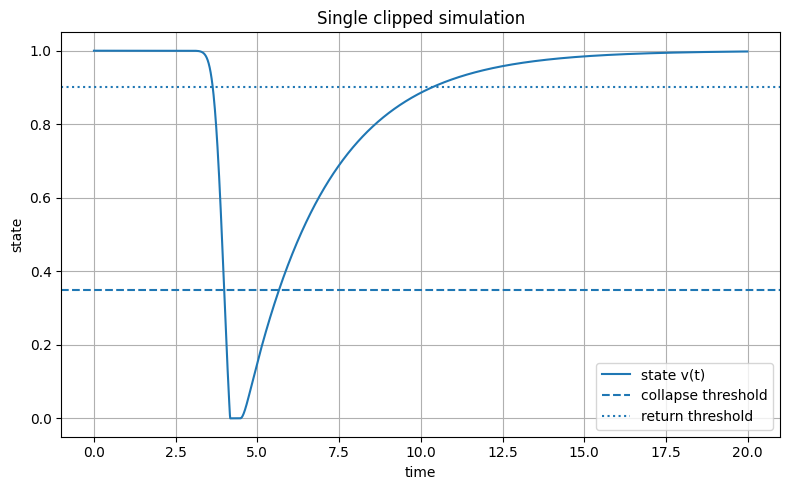

In [3]:

params = ModelParams()
t, u, v = simulate_recovery_clipped(params, load=1.5, rise_time=0.25)
metrics_example = extract_metrics_strict(
    t,
    u,
    v,
    collapse_threshold=params.collapse_threshold,
    return_tol=params.return_tol,
    max_return_time=6.0,
)

print(metrics_example)

plt.plot(t, v, label="state v(t)")
plt.axhline(params.collapse_threshold, linestyle="--", label="collapse threshold")
plt.axhline(params.return_tol, linestyle=":", label="return threshold")
plt.xlabel("time")
plt.ylabel("state")
plt.title("Single clipped simulation")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "single_clipped_simulation.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Parameter sweep

In [4]:

loads = np.linspace(0.2, 3.0, 18)
rise_times = np.linspace(0.08, 1.5, 16)

rows = []
for load in loads:
    for rise_time in rise_times:
        t, u, v = simulate_recovery_clipped(params, load=load, rise_time=rise_time)
        m = extract_metrics_strict(
            t,
            u,
            v,
            collapse_threshold=params.collapse_threshold,
            return_tol=params.return_tol,
            max_return_time=6.0,
            final_window_points=50,
            require_stable_final=True,
        )
        rows.append({"load": load, "rise_time": rise_time, **m})

df_clip_strict = pd.DataFrame(rows)
df_clip_strict.head()


,load,rise_time,v_min,collapsed,collapse_time,returned,tau_return,tau_return_raw,critical_window_W,final_mean,boundary_crossed
0,0.2,0.080000,0.815919,False,NaN,True,1.56,1.56,0.0,0.999634,False
1,0.2,0.174667,0.830013,False,NaN,True,1.40,1.40,0.0,0.999634,False
2,0.2,0.269333,0.841517,False,NaN,True,1.28,1.28,0.0,0.999632,False
3,0.2,0.364000,0.851319,False,NaN,True,1.18,1.18,0.0,0.999631,False
4,0.2,0.458667,0.859855,False,NaN,True,1.09,1.09,0.0,0.999628,False


## 5. Boundary map

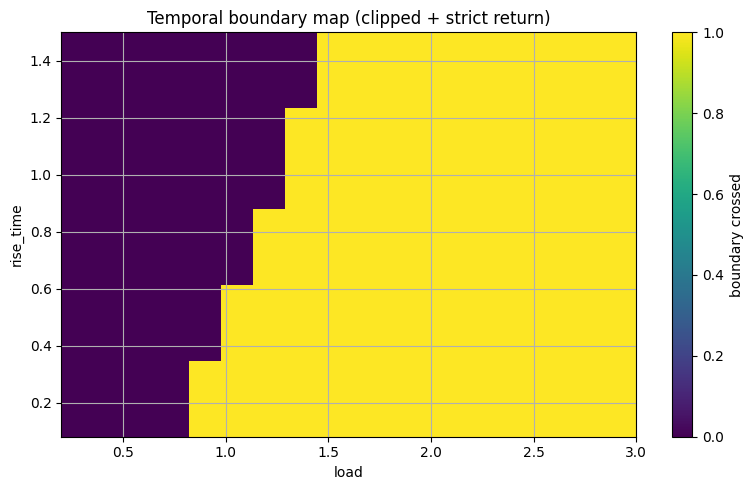

In [5]:

pivot_boundary = df_clip_strict.pivot(index="rise_time", columns="load", values="boundary_crossed")

plt.imshow(
    pivot_boundary.values,
    aspect="auto",
    origin="lower",
    extent=[
        pivot_boundary.columns.min(),
        pivot_boundary.columns.max(),
        pivot_boundary.index.min(),
        pivot_boundary.index.max(),
    ],
)
plt.colorbar(label="boundary crossed")
plt.xlabel("load")
plt.ylabel("rise_time")
plt.title("Temporal boundary map (clipped + strict return)")
plt.tight_layout()
plt.savefig(fig_dir / "boundary_map_clipped_strict.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Return map

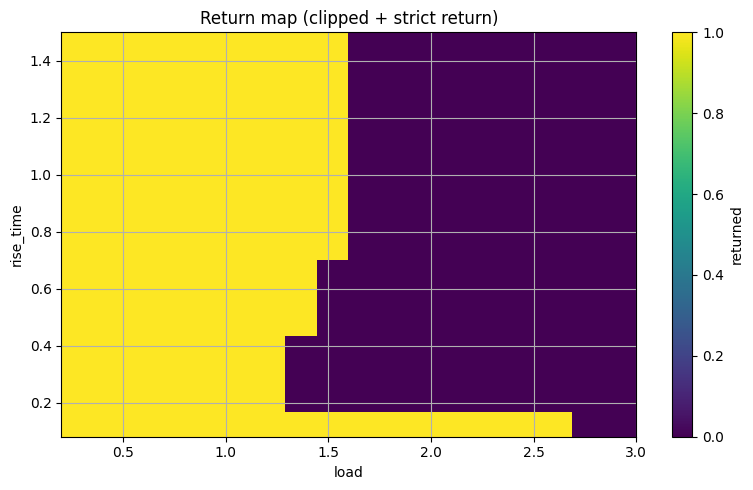

In [6]:

pivot_returned = df_clip_strict.pivot(index="rise_time", columns="load", values="returned")

plt.imshow(
    pivot_returned.values,
    aspect="auto",
    origin="lower",
    extent=[
        pivot_returned.columns.min(),
        pivot_returned.columns.max(),
        pivot_returned.index.min(),
        pivot_returned.index.max(),
    ],
)
plt.colorbar(label="returned")
plt.xlabel("load")
plt.ylabel("rise_time")
plt.title("Return map (clipped + strict return)")
plt.tight_layout()
plt.savefig(fig_dir / "return_map_clipped_strict.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Recovery time vs load

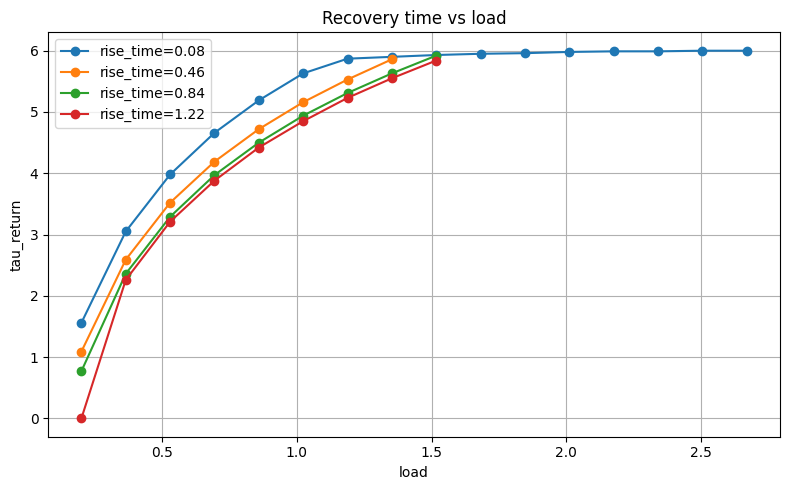

In [7]:

valid = df_clip_strict[df_clip_strict["returned"] == True]

for rt in sorted(valid["rise_time"].unique())[::4]:
    sub = valid[np.isclose(valid["rise_time"], rt)]
    plt.plot(sub["load"], sub["tau_return"], marker="o", label=f"rise_time={rt:.2f}")

plt.xlabel("load")
plt.ylabel("tau_return")
plt.title("Recovery time vs load")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "recovery_time_vs_load.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Critical load curve

In [8]:

critical_rows = []
for rt in sorted(df_clip_strict["rise_time"].unique()):
    sub = df_clip_strict[np.isclose(df_clip_strict["rise_time"], rt)].sort_values("load")
    crossed = sub[sub["boundary_crossed"] == True]
    crit = crossed["load"].iloc[0] if len(crossed) else np.nan
    critical_rows.append({"rise_time": rt, "critical_load": crit})

df_crit_clip_strict = pd.DataFrame(critical_rows)
df_crit_clip_strict


,rise_time,critical_load
0,0.080000,0.858824
1,0.174667,0.858824
2,0.269333,0.858824
3,0.364000,1.023529
4,0.458667,1.023529
5,0.553333,1.023529
6,0.648000,1.188235
7,0.742667,1.188235
8,0.837333,1.188235
9,0.932000,1.352941


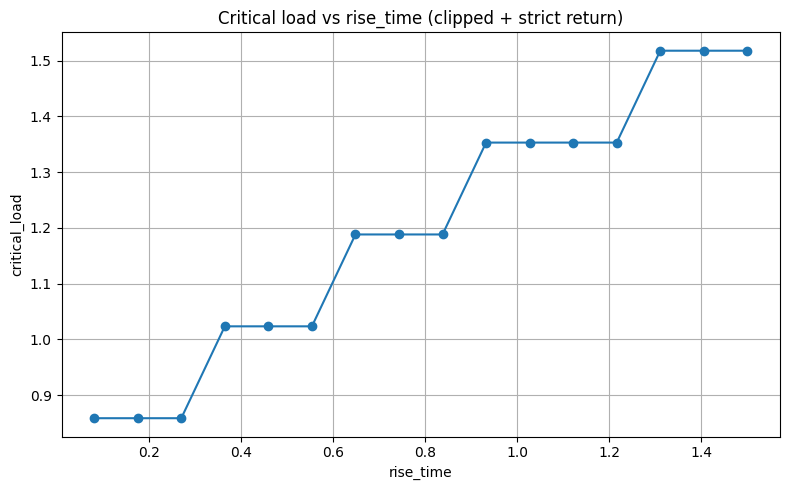

In [9]:

plt.plot(df_crit_clip_strict["rise_time"], df_crit_clip_strict["critical_load"], marker="o")
plt.xlabel("rise_time")
plt.ylabel("critical_load")
plt.title("Critical load vs rise_time (clipped + strict return)")
plt.tight_layout()
plt.savefig(fig_dir / "critical_load_vs_rise_time.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Return probability by load bin

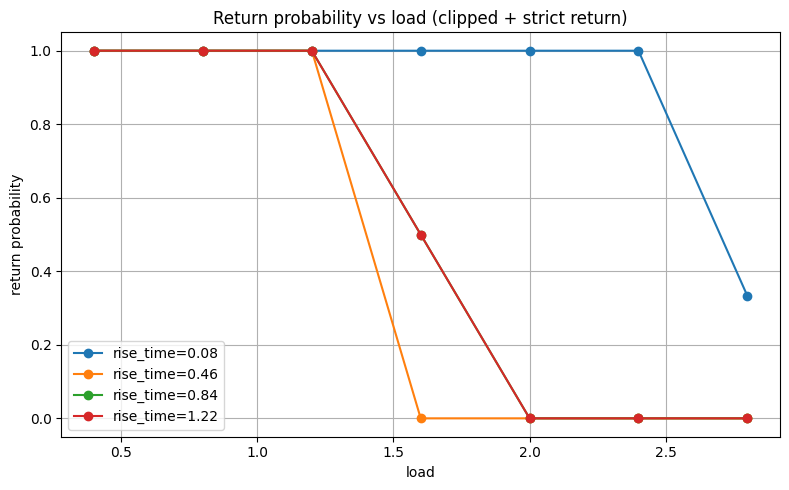

In [10]:

for rt in sorted(df_clip_strict["rise_time"].unique())[::4]:
    sub = df_clip_strict[np.isclose(df_clip_strict["rise_time"], rt)].copy()
    bins = np.linspace(sub["load"].min(), sub["load"].max(), 8)
    sub["load_bin"] = pd.cut(sub["load"], bins, include_lowest=True)
    grp = sub.groupby("load_bin", observed=False)["returned"].mean().reset_index()
    centers = [interval.mid for interval in grp["load_bin"]]
    plt.plot(centers, grp["returned"], marker="o", label=f"rise_time={rt:.2f}")

plt.xlabel("load")
plt.ylabel("return probability")
plt.title("Return probability vs load (clipped + strict return)")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "return_probability_vs_load.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Summary statistics

In [11]:

boundary_fraction = df_clip_strict["boundary_crossed"].mean()
return_fraction = df_clip_strict["returned"].mean()

print("Boundary crossed fraction:", boundary_fraction)
print("Return fraction:", return_fraction)


Boundary crossed fraction: 0.6631944444444444
Return fraction: 0.4930555555555556


In [12]:

final_summary = df_clip_strict.groupby("boundary_crossed")[[
    "tau_return",
    "critical_window_W",
    "v_min",
    "final_mean",
]].mean()

final_summary


,tau_return,critical_window_W,v_min,final_mean
boundary_crossed,,,,
False,3.424948,1.609588,0.638298,0.998716
True,5.661111,4.966702,0.052192,0.996816


## 11. Critical-load trend diagnostics

In [13]:

df_crit_clip_strict.corr(numeric_only=True)


,rise_time,critical_load
rise_time,1.000000,0.979905
critical_load,0.979905,1.000000


In [14]:

x = df_crit_clip_strict["rise_time"].values
y = df_crit_clip_strict["critical_load"].values
coef = np.polyfit(x, y, 1)
print("Slope:", coef[0])


Slope: 0.514279448316195


## 12. Save data outputs

In [15]:

df_clip_strict.to_csv(data_dir / "recovery_results_strict.csv", index=False)
df_crit_clip_strict.to_csv(data_dir / "critical_load_curve_strict.csv", index=False)

print("Saved files:")
for p in sorted(output_dir.rglob("*")):
    if p.is_file():
        print("-", p)


Saved files:
- results_recovery_boundary/data/critical_load_curve_strict.csv
- results_recovery_boundary/data/recovery_results_strict.csv
- results_recovery_boundary/figures/boundary_map_clipped_strict.png
- results_recovery_boundary/figures/critical_load_vs_rise_time.png
- results_recovery_boundary/figures/recovery_time_vs_load.png
- results_recovery_boundary/figures/return_map_clipped_strict.png
- results_recovery_boundary/figures/return_probability_vs_load.png
- results_recovery_boundary/figures/single_clipped_simulation.png



## Conclusion

The model exhibits a clear boundary separating recoverable and non-recoverable regimes in `(load, rise_time)` space.

Critical load increases monotonically with `rise_time`, suggesting that slower perturbations allow the system to sustain higher demand before crossing the recovery boundary.

This supports a timescale-dependent view of failure: the system appears to fail not only as a function of absolute load, but when demand rises faster than recovery can compensate within a finite window.
